In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp -r /content/drive/MyDrive/SUN/PIL-main /content/

In [ ]:
!cp -r "/content/drive/My Drive/SUN/meudon_new" /content/

In [ ]:
%cd /content/PIL-main
!pip install astropy scikit-image plotly imageio

/content/PIL-main


In [ ]:

############################################
# 1. Imports
############################################

import os
import re
import random
import torch
import numpy as np
from astropy.io import fits
from skimage.transform import resize
from PIL import Image

from scripts.neutralliner import NeutralLiner
from scripts.imagedata import ImageData
from scripts.config import FITS_SHAPE
from scripts.imagedata import ImageData

############################################
# 2. Paths
############################################

MEUDON_PATH = "/content/meudon_new"

SAVE_BASE = "/content/drive/MyDrive/CaK_POL_fits1957/STEP_SIZE_1"

os.makedirs(SAVE_BASE, exist_ok=True)


############################################
# 4. Find available Meudon CRs
############################################

meudon_crs = []

for f in os.listdir(MEUDON_PATH):
    if f.endswith(".png"):
        cr = int(f.split(".")[0])
        meudon_crs.append(cr)

meudon_crs = sorted(meudon_crs)

print("Available Meudon CRs:", len(meudon_crs))


############################################
# 5. Select CRs for training
############################################

# N_CRS = 10

# selected_crs = random.sample(meudon_crs, N_CRS)
selected_crs = [1957]

print("Selected CRs:", selected_crs)


############################################
# 6. Training parameters
############################################

MODELS_PER_CR = 100
EPOCHS = 6000

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)


Available Meudon CRs: 1048
Selected CRs: [1957]
Using device: cuda


In [ ]:
############################################
# build_image_data()
# Simple polarity-sign supervision
############################################

from astropy.io import fits
from scipy.ndimage import gaussian_filter
from skimage.transform import resize
from PIL import Image
import numpy as np
import os

from scripts.imagedata import ImageData
from scripts.config import FITS_SHAPE


def build_image_data(cr):

    # ==========================================
    # PATHS
    # ==========================================

    meudon_file = os.path.join(
        MEUDON_PATH,
        f"{cr}.png"
    )

    fits_file = f"/content/{cr}.fits"


    # ==========================================
    # 1. LOAD FILAMENT MAP
    # ==========================================

    img = Image.open(
        meudon_file
    ).convert("L")

    filament = np.array(img).astype(float)

    # normalize
    filament = (
        filament - filament.min()
    ) / (
        filament.max() - filament.min()
    )

    # invert because filaments are dark
    filament = 1 - filament

    # flip vertically if needed
    filament = np.flipud(filament)


    # ==========================================
    # 2. LOAD MAGNETIC MAP
    # ==========================================

    with fits.open(fits_file) as hdul:

        mag = hdul[0].data


    # ==========================================
    # 3. REMOVE NaNs
    # ==========================================

    mag = np.nan_to_num(mag)


    # ==========================================
    # 4. OPTIONAL POLARITY FLIP
    # ==========================================

    mag = -mag


    # ==========================================
    # 5. IDENTICAL CROPPING
    # ==========================================

    TOP_CROP = 0
    BOTTOM_CROP = 0

    LEFT_CROP = 0
    RIGHT_CROP = 0


    mag = mag[
        TOP_CROP : mag.shape[0] - BOTTOM_CROP,
        LEFT_CROP : mag.shape[1] - RIGHT_CROP
    ]


    TOP_CROP = 0
    BOTTOM_CROP = 0

    LEFT_CROP = 40
    RIGHT_CROP = 40

    filament = filament[
        TOP_CROP : filament.shape[0] - BOTTOM_CROP,
        LEFT_CROP : filament.shape[1] - RIGHT_CROP
    ]


    # ==========================================
    # 6. SMOOTH MAGNETIC FIELD
    # ==========================================
    # print("mag" , mag)

    mag = gaussian_filter(
        mag,
        sigma=2
    )

    # print("mag", mag)

    # ==========================================
    # 7. RESIZE BOTH MAPS
    # ==========================================

    mag = resize(
        mag,
        FITS_SHAPE,
        anti_aliasing=True
    )

    filament = resize(
        filament,
        FITS_SHAPE,
        anti_aliasing=True
    )


    # ==========================================
    # 8. NORMALIZE
    # ==========================================

    # mag = mag / np.max(np.abs(mag))


    # ==========================================
    # 9. CONVERT TO SIGN MAP
    # ==========================================

    mag = np.sign(mag).astype(np.int8)

    # print("mag", mag)
    # print(filament)

    # ==========================================
    # 10. FILAMENT THRESHOLD
    # ==========================================

    filament = np.flipud(filament)

    filament = filament > 0.7

    # print(filament)

    # ==========================================
    # 11. CREATE ImageData
    # ==========================================

    img_data = ImageData(
        filament,
        data_mode="img"
    )

    img_data.target_img = mag


    # ==========================================
    # 12. FIX DIMENSIONS
    # ==========================================

    h, w = img_data.img_array.shape

    img_data.height = h
    img_data.width = w

    return img_data

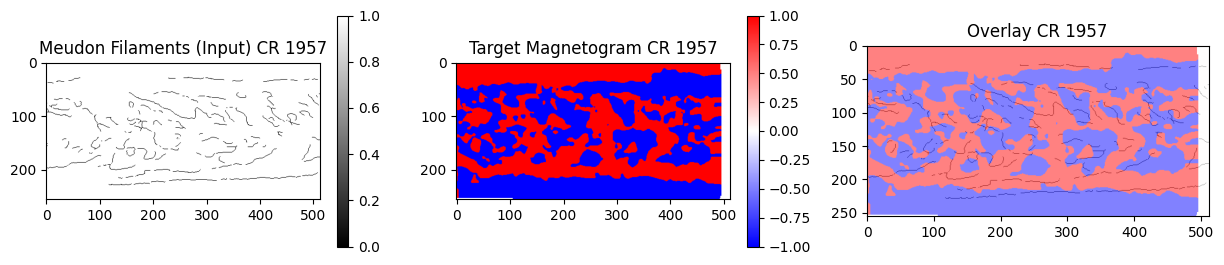

In [ ]:
import matplotlib.pyplot as plt

cr = 1957  # or any CR you selected
img_data = build_image_data(cr)

filament = img_data.img_array
target = img_data.target_img

plt.figure(figsize=(15,3))

plt.subplot(1,3,1)
plt.title(f"Meudon Filaments (Input) CR {cr}")
plt.imshow(filament, cmap='gray')
plt.colorbar()

plt.subplot(1,3,2)
plt.title(f"Target Magnetogram CR {cr}")
plt.imshow(target, cmap='bwr')  # blue-red for ±1
plt.colorbar()

plt.subplot(1,3,3)
plt.imshow(target, cmap='bwr', alpha=0.7)
plt.imshow(filament, cmap='gray', alpha=0.3)

plt.title(f"Overlay CR {cr}")
plt.show()

plt.show()

In [ ]:
############################################
# 8. TRAINING LOOP
############################################

for cr in selected_crs:

    # if cr not in mcintosh_index:
    #     print("Skipping CR", cr, "(no McIntosh)")
    #     continue

    print("\n==============================")
    print("Training CR", cr)
    print("==============================")

    img = build_image_data(cr)

    CR_SAVE = f"{SAVE_BASE}/model_CR_{cr}"
    os.makedirs(CR_SAVE, exist_ok=True)

    ########################################
    # Train multiple models per CR
    ########################################

    for k in range(MODELS_PER_CR):

        model_path = f"{CR_SAVE}/model_{k}.pth"

        if os.path.exists(model_path):
            print(f"Model {k} already exists, skipping")
            continue

        print(f"\nTraining model {k} for CR {cr}")

        # help_step_size=None

        model = NeutralLiner(
            image_list=[img],
            lr=5e-3,
            help_step_size=1,   # you can set None later
            device=device
        )

        # if help_step_size is None and not hasattr(model, "targets"):
        #   model.targets = [None] * len(model.image_list)

        model.to(device)

        model.start_training(
            num_epochs=EPOCHS,
            need_plot=False
        )

        ####################################
        # Save trained model
        ####################################
        torch.save(
            model.state_dict(),
            model_path
        )

        print("Saved:", model_path)


Training CR 1957

Training model 0 for CR 1957
Saved: /content/drive/MyDrive/CaK_POL_fits1957/STEP_SIZE_1/model_CR_1957/model_0.pth

Training model 1 for CR 1957
Saved: /content/drive/MyDrive/CaK_POL_fits1957/STEP_SIZE_1/model_CR_1957/model_1.pth

Training model 2 for CR 1957
Saved: /content/drive/MyDrive/CaK_POL_fits1957/STEP_SIZE_1/model_CR_1957/model_2.pth

Training model 3 for CR 1957
Saved: /content/drive/MyDrive/CaK_POL_fits1957/STEP_SIZE_1/model_CR_1957/model_3.pth

Training model 4 for CR 1957
Saved: /content/drive/MyDrive/CaK_POL_fits1957/STEP_SIZE_1/model_CR_1957/model_4.pth

Training model 5 for CR 1957
Saved: /content/drive/MyDrive/CaK_POL_fits1957/STEP_SIZE_1/model_CR_1957/model_5.pth

Training model 6 for CR 1957
Saved: /content/drive/MyDrive/CaK_POL_fits1957/STEP_SIZE_1/model_CR_1957/model_6.pth

Training model 7 for CR 1957
Saved: /content/drive/MyDrive/CaK_POL_fits1957/STEP_SIZE_1/model_CR_1957/model_7.pth

Training model 8 for CR 1957
Saved: /content/drive/MyDrive/Ca

Processing CR 1957


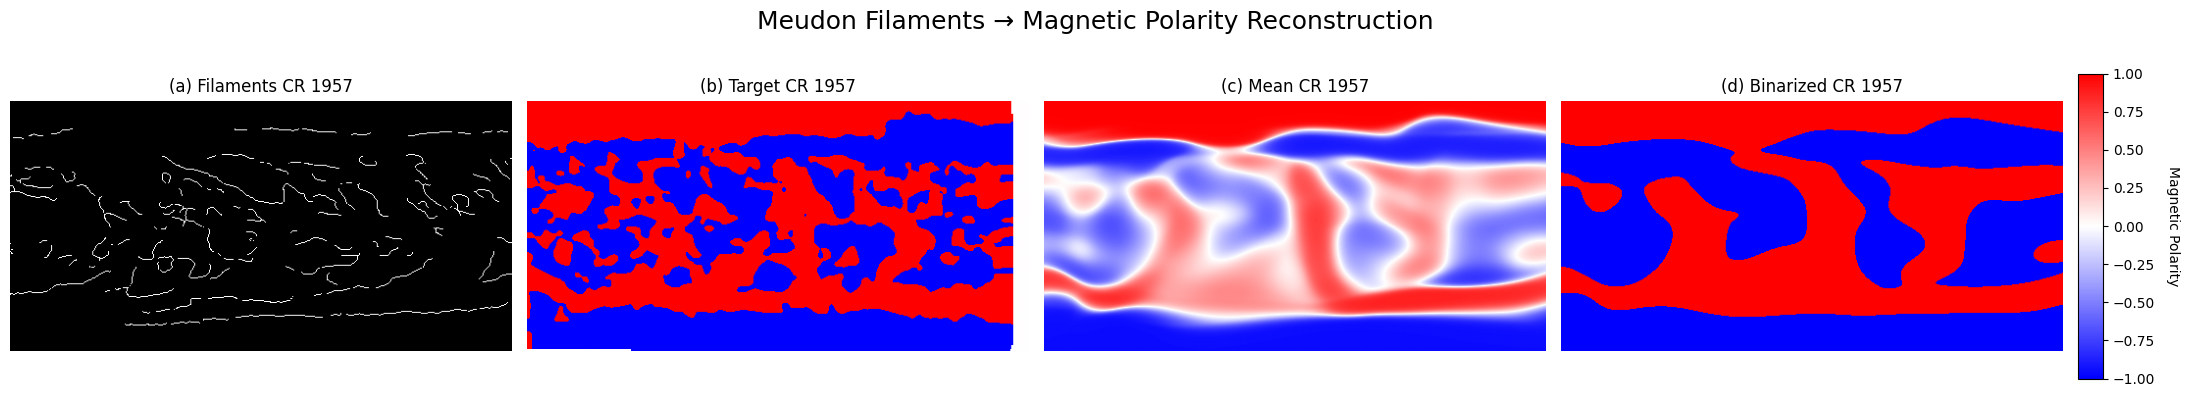

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import os

selected_crs = [1957]   # add more CRs later

fig, axes = plt.subplots(
    len(selected_crs),
    5,
    figsize=(22, 4*len(selected_crs)),
    gridspec_kw={
        "width_ratios":[1,1,1,1,0.05]
    }
)

if len(selected_crs) == 1:
    axes = axes.reshape(1, 5)

for row, cr in enumerate(selected_crs):

    print(f"Processing CR {cr}")

    img_data = build_image_data(cr)

    model_dir = f"{SAVE_BASE}/model_CR_{cr}"

    preds = []

    # ==========================================
    # Load ensemble
    # ==========================================

    for mf in os.listdir(model_dir):

        if not mf.endswith(".pth"):
            continue

        model = NeutralLiner(
            image_list=[img_data],
            lr=5e-3,
            help_step_size=1,
            device=device
        )

        if not hasattr(model, "targets"):
            model.targets = [None] * len(model.image_list)

        model.load_state_dict(
            torch.load(
                os.path.join(model_dir, mf),
                map_location=device
            )
        )

        model.to(device)

        with torch.no_grad():

            pred = model(
                model.data_list[0]
            ).cpu().numpy()

        preds.append(pred)

    preds = np.stack(preds)

    pred_mean = np.mean(
        preds,
        axis=0
    )

    pred_map = pred_mean.reshape(
        img_data.img_array.shape
    )

    binary_map = np.sign(pred_map)

    # ==========================================
    # Filament panel
    # ==========================================

    filament_display = (
        1 - img_data.img_array.astype(float)
    ) ** 0.25

    axes[row,0].imshow(
        filament_display,
        cmap="gray"
    )

    axes[row,0].set_title(
        f"(a) Filaments CR {cr}"
    )

    axes[row,0].axis("off")

    # ==========================================
    # Target panel
    # ==========================================

    axes[row,1].imshow(
        img_data.target_img,
        cmap="bwr",
        vmin=-1,
        vmax=1
    )

    axes[row,1].set_title(
        f"(b) Target CR {cr}"
    )

    axes[row,1].axis("off")

    # ==========================================
    # Mean prediction
    # ==========================================

    im = axes[row,2].imshow(
        pred_map,
        cmap="bwr",
        vmin=-1,
        vmax=1
    )

    axes[row,2].set_title(
        f"(c) Mean CR {cr}"
    )

    axes[row,2].axis("off")

    # ==========================================
    # Binarized prediction
    # ==========================================

    axes[row,3].imshow(
        binary_map,
        cmap="bwr",
        vmin=-1,
        vmax=1
    )

    axes[row,3].set_title(
        f"(d) Binarized CR {cr}"
    )

    axes[row,3].axis("off")

    # ==========================================
    # Colorbar at FAR RIGHT
    # ==========================================

    cax = axes[row,4]

    cbar = fig.colorbar(
        im,
        cax=cax
    )

    cbar.set_label(
        "Magnetic Polarity",
        rotation=270,
        labelpad=18
    )

plt.suptitle(
    "Meudon Filaments → Magnetic Polarity Reconstruction",
    fontsize=18
)

plt.tight_layout(
    rect=[0,0,1,0.97]
)

plt.show()